## **LIBRARY**

In [108]:
from qiskit import QuantumCircuit, transpile
from qiskit.primitives import StatevectorSampler
import matplotlib as plt
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import numpy as np

## **INISIALISASI**

In [109]:
#inisialisasi
target ='11001001'
n = len(target)
N = 2**n

## **ORACLE**

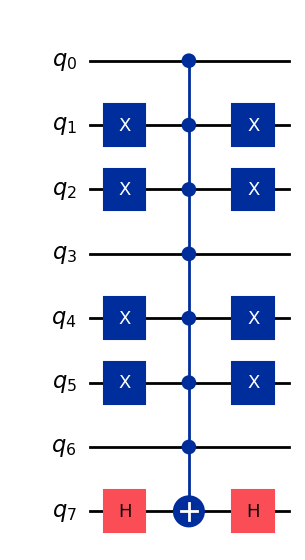

In [110]:
#oracle
def quantum_oracle(target):
    #ancilla
    oracle = QuantumCircuit(n, name= 'Oracle')

    #menerapkan X-gate setiap menemukan |0>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            oracle.x(i)

    #menerapkan multi controlled Z-gate untuk setiap qubit
    oracle.h(n-1)
    oracle.mcx(list(range(n-1)), n-1)
    oracle.h(n-1)

    #menerapkan X-gate untuk menemukan |0>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            oracle.x(i)

    #membuat black box
    oracle.to_gate()

    return oracle

quantum_oracle(target).draw('mpl')
    

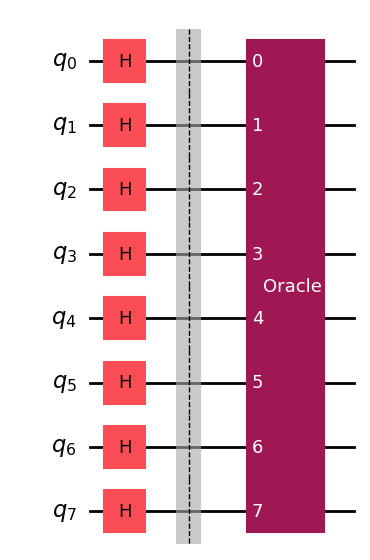

In [111]:
#inisialisasi oracle
co = QuantumCircuit(n)
co.h(list(range(n)))
co.barrier()
co.append(quantum_oracle(target), list(range(n)))

co.draw('mpl')

In [112]:
#simulasi
simulator = Aer.get_backend("statevector_simulator")
job = transpile(co, simulator)
result = simulator.run(job).result()
counts = result.get_counts(job)

#mengambil amplitudo setiap keadaan
statevector = result.get_statevector()

#menampilkan amplitudo setiap keadaan
for i, amp in enumerate(np.asarray(statevector)):
    print(f"Amplitude |{bin(i)[2:].zfill(len(target))}> : {amp:.2f}")

#plot_histogram(counts)

Amplitude |00000000> : 0.06+0.00j
Amplitude |00000001> : 0.06+0.00j
Amplitude |00000010> : 0.06+0.00j
Amplitude |00000011> : 0.06+0.00j
Amplitude |00000100> : 0.06+0.00j
Amplitude |00000101> : 0.06+0.00j
Amplitude |00000110> : 0.06+0.00j
Amplitude |00000111> : 0.06+0.00j
Amplitude |00001000> : 0.06+0.00j
Amplitude |00001001> : 0.06+0.00j
Amplitude |00001010> : 0.06+0.00j
Amplitude |00001011> : 0.06+0.00j
Amplitude |00001100> : 0.06+0.00j
Amplitude |00001101> : 0.06+0.00j
Amplitude |00001110> : 0.06+0.00j
Amplitude |00001111> : 0.06+0.00j
Amplitude |00010000> : 0.06+0.00j
Amplitude |00010001> : 0.06+0.00j
Amplitude |00010010> : 0.06+0.00j
Amplitude |00010011> : 0.06+0.00j
Amplitude |00010100> : 0.06+0.00j
Amplitude |00010101> : 0.06+0.00j
Amplitude |00010110> : 0.06+0.00j
Amplitude |00010111> : 0.06+0.00j
Amplitude |00011000> : 0.06+0.00j
Amplitude |00011001> : 0.06+0.00j
Amplitude |00011010> : 0.06+0.00j
Amplitude |00011011> : 0.06+0.00j
Amplitude |00011100> : 0.06+0.00j
Amplitude |000

## **DIFFUSION**

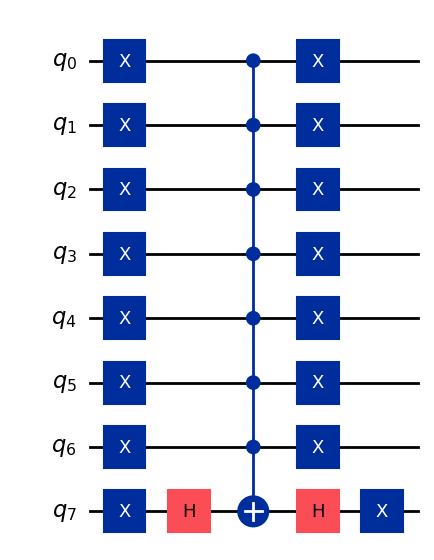

In [113]:
def quantum_diffusion(target):
    dif = QuantumCircuit(len(target), name='Diffusion')

    #X-gate untuk semua qubit
    dif.x(list(range(len(target))))

    #menerapkan multi controlled Z-gate untuk semua qubit
    dif.h(len(target)-1)
    dif.mcx(list(range(len(target)-1)), len(target)-1)
    dif.h(len(target)-1)

    #menerapkan X-gate untuk menemukan |0>
    dif.x(list(range(len(target))))

    #membuat black box
    #oracle.to_gate()

    return dif

quantum_diffusion(target).draw('mpl')


## **ORACLE & DIFFUSION**

In [114]:
#inisialisasi
gc = QuantumCircuit(n)
gc.h(list(range(n)))

#menerapkan oracle & diffusion
gc.append(quantum_oracle(target), list(range(n)))
gc.h(list(range(n)))
gc.append(quantum_diffusion(target), list(range(n)))
gc.h(list(range(n)))

#simulasi
simulator = Aer.get_backend("statevector_simulator")
job = transpile(gc, simulator)
result = simulator.run(job).result()

#ambil amplitudo setiap keadaan
statevector = result.get_statevector()

#menampilkan amplitudo
for i, amp in enumerate(np.asarray(statevector)):
    print(f"Amplitude |{bin(i)[2:].zfill(n)}> : {amp:.2f}")



Amplitude |00000000> : -0.06-0.00j
Amplitude |00000001> : -0.06-0.00j
Amplitude |00000010> : -0.06-0.00j
Amplitude |00000011> : -0.06-0.00j
Amplitude |00000100> : -0.06-0.00j
Amplitude |00000101> : -0.06-0.00j
Amplitude |00000110> : -0.06-0.00j
Amplitude |00000111> : -0.06-0.00j
Amplitude |00001000> : -0.06-0.00j
Amplitude |00001001> : -0.06-0.00j
Amplitude |00001010> : -0.06-0.00j
Amplitude |00001011> : -0.06-0.00j
Amplitude |00001100> : -0.06-0.00j
Amplitude |00001101> : -0.06-0.00j
Amplitude |00001110> : -0.06-0.00j
Amplitude |00001111> : -0.06-0.00j
Amplitude |00010000> : -0.06-0.00j
Amplitude |00010001> : -0.06-0.00j
Amplitude |00010010> : -0.06-0.00j
Amplitude |00010011> : -0.06-0.00j
Amplitude |00010100> : -0.06-0.00j
Amplitude |00010101> : -0.06-0.00j
Amplitude |00010110> : -0.06-0.00j
Amplitude |00010111> : -0.06-0.00j
Amplitude |00011000> : -0.06-0.00j
Amplitude |00011001> : -0.06-0.00j
Amplitude |00011010> : -0.06-0.00j
Amplitude |00011011> : -0.06-0.00j
Amplitude |00011100>

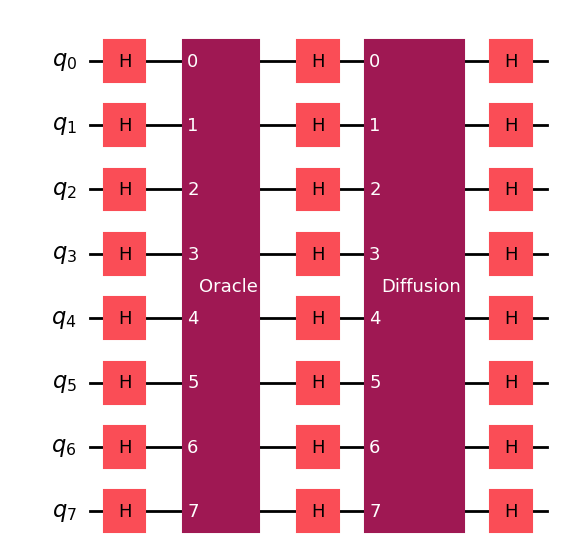

In [115]:
gc.draw('mpl')

## **MEASUREMENT**

In [ ]:
gc = QuantumCircuit(n)
gc.h(range(n))